# Exploración de fuentes — Observatorio de la Economía del Cuidado (PP 7)

**Objetivo:** responder, con los datos reales y no con la descripción de las fuentes, las tres preguntas del equipo:
1. **Granularidad** — ¿a qué nivel territorial llega cada fuente?
2. **Antigüedad** — ¿qué tan reciente es el dato?
3. **Tamaño de muestra** — ¿aguanta la segmentación territorial?

Y hacer una primera prueba de las hipótesis H1 (brecha intra-alcaldía) y H2 (desiertos de cuidado).

| Fuente | Rol en el Observatorio | Versión usada |
|---|---|---|
| DENUE (INEGI) | Oferta formal de cuidados, georreferenciada | 05/2026 |
| Censo 2020, AGEB urbana (INEGI) | Demanda potencial de cuidados | 2020 |
| ENUT 2024 (INEGI) | Horas de cuidado no remunerado, CDMX vs. nacional | 2024 |
| ENASIC 2022 (INEGI) | Perfil nacional de personas cuidadoras | 2022 |

**Cómo correrlo:** ejecutar de arriba abajo. La primera celda descarga las fuentes del INEGI a `data/raw/` si no existen (~80 MB comprimidos). Todo lo que se genera va a `data/curada/` y `figuras/`.

> Capa **cruda** = `data/raw/` (descargas sin tocar) · Capa **curada** = `data/curada/` (tablas limpias con CVEGEO homologado). Es la arquitectura por capas del WORKFLOW, paso 1.2.

In [1]:
from pathlib import Path
import shutil, urllib.request, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 200)

# Raíz del repo: los notebooks viven en notebooks/, así que subimos un nivel.
# Así `data/` y `figuras/` se resuelven igual desde Jupyter o desde la raíz.
BASE = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RAW, CUR, FIG = BASE / 'data' / 'raw', BASE / 'data' / 'curada', BASE / 'figuras'
for p in (RAW, CUR, FIG):
    p.mkdir(parents=True, exist_ok=True)

FUENTES = {
    'denue_09': 'https://www.inegi.org.mx/contenidos/masiva/denue/denue_09_csv.zip',
    'censo_ageb_09': 'https://www.inegi.org.mx/contenidos/programas/ccpv/2020/datosabiertos/ageb_manzana/ageb_mza_urbana_09_cpv2020_csv.zip',
    'enut_2024': 'https://www.inegi.org.mx/contenidos/programas/enut/2024/datosabiertos/conjunto_de_datos_enut_2024_csv.zip',
    'enasic_2022': 'https://www.inegi.org.mx/contenidos/programas/enasic/2022/datosabiertos/conjunto_de_datos_enasic_2022_csv.zip',
}

def descargar(nombre, url):
    """Descarga y descomprime una fuente solo si no existe ya en data/raw."""
    zpath, dpath = RAW / f'{nombre}.zip', RAW / nombre
    if not zpath.exists():
        print(f'Descargando {nombre}...')
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req) as r, open(zpath, 'wb') as f:
            shutil.copyfileobj(r, f)
    if not dpath.exists():
        with zipfile.ZipFile(zpath) as z:
            z.extractall(dpath)
    return dpath

DIRS = {k: descargar(k, u) for k, u in FUENTES.items()}
{k: f'{(RAW / (k + ".zip")).stat().st_size / 1e6:.1f} MB' for k in DIRS}

{'denue_09': '45.4 MB',
 'censo_ageb_09': '13.0 MB',
 'enut_2024': '15.9 MB',
 'enasic_2022': '3.2 MB'}

---
## 1. DENUE — oferta formal de cuidados

El DENUE trae cada establecimiento con su código SCIAN, coordenadas y clave de AGEB. Definimos qué cuenta como **establecimiento de cuidado** revisando todos los códigos de los subsectores 623 y 624 que aparecen en la CDMX.

**Incluidos:** guarderías, residencias/asilos para personas mayores, **centros de día para personas mayores y con discapacidad** (`624121/624122`, omitidos en nuestra primera lista), residencias con enfermería o para discapacidad intelectual, orfanatos y residencias asistenciales, y comedores comunitarios (apoyo indirecto al cuidado).

**Excluidos a propósito:** grupos de autoayuda para adicciones (`624191`, 1,300+ registros que inflarían la oferta), residencias para adicciones, servicios de orientación y trabajo social, refugios y capacitación para el trabajo. No son cuidado directo de personas dependientes.

In [2]:
denue = pd.read_csv(next(DIRS['denue_09'].rglob('conjunto_de_datos/*.csv')),
                    encoding='latin-1', dtype=str, low_memory=False)

CATEGORIAS = {
    '624411': ('Infancia', 'Guardería', 'Privado'),
    '624412': ('Infancia', 'Guardería', 'Público'),
    '623311': ('Personas mayores', 'Residencia / asilo', 'Privado'),
    '623312': ('Personas mayores', 'Residencia / asilo', 'Público'),
    '624121': ('Personas mayores y discapacidad', 'Centro de día', 'Privado'),
    '624122': ('Personas mayores y discapacidad', 'Centro de día', 'Público'),
    '623111': ('Salud y discapacidad', 'Residencia con enfermería', 'Privado'),
    '623112': ('Salud y discapacidad', 'Residencia con enfermería', 'Público'),
    '623211': ('Salud y discapacidad', 'Residencia discapacidad intelectual', 'Privado'),
    '623212': ('Salud y discapacidad', 'Residencia discapacidad intelectual', 'Público'),
    '623991': ('Asistencia social', 'Orfanato / residencia asistencial', 'Privado'),
    '623992': ('Asistencia social', 'Orfanato / residencia asistencial', 'Público'),
    '624211': ('Apoyo comunitario', 'Comedor comunitario', 'Privado'),
    '624212': ('Apoyo comunitario', 'Comedor comunitario', 'Público'),
}

cuidado = denue[denue['codigo_act'].isin(CATEGORIAS)].copy()
cuidado[['grupo', 'tipo', 'sector']] = pd.DataFrame(
    cuidado['codigo_act'].map(CATEGORIAS).tolist(), index=cuidado.index)
cuidado['lat'] = pd.to_numeric(cuidado['latitud'], errors='coerce')
cuidado['lon'] = pd.to_numeric(cuidado['longitud'], errors='coerce')
cuidado['CVEGEO_AGEB'] = cuidado['cve_ent'] + cuidado['cve_mun'] + cuidado['cve_loc'] + cuidado['ageb']
cuidado['cve_mun'] = cuidado['cve_mun'].str.zfill(3)

print(f'DENUE CDMX: {len(denue):,} establecimientos en total · {len(cuidado):,} de cuidado')
print('Sin coordenadas:', cuidado[['lat', 'lon']].isna().any(axis=1).sum())
pd.crosstab([cuidado['grupo'], cuidado['tipo']], cuidado['sector'], margins=True, margins_name='Total')

DENUE CDMX: 462,732 establecimientos en total · 1,463 de cuidado
Sin coordenadas: 0


sector                                                               Privado  Público  Total
grupo                           tipo                                                        
Apoyo comunitario               Comedor comunitario                      109      351    460
Asistencia social               Orfanato / residencia asistencial        107       24    131
Infancia                        Guardería                                340      263    603
Personas mayores                Residencia / asilo                        88       21    109
Personas mayores y discapacidad Centro de día                             22      104    126
Salud y discapacidad            Residencia con enfermería                 12        4     16
                                Residencia discapacidad intelectual       17        1     18
Total                                                                    695      768   1463

**Escala de los establecimientos.** El DENUE no trae capacidad (lugares disponibles), solo rango de personal ocupado. Es una limitación importante: un conteo de establecimientos no equivale a cobertura.

In [3]:
orden = ['0 a 5 personas', '6 a 10 personas', '11 a 30 personas', '31 a 50 personas',
         '51 a 100 personas', '101 a 250 personas', '251 y más personas']
tam = pd.crosstab(cuidado['tipo'], cuidado['per_ocu']).reindex(columns=orden, fill_value=0)
tam['% con ≤10 personas'] = (tam[orden[:2]].sum(axis=1) / tam[orden].sum(axis=1) * 100).round(1)
tam

per_ocu,0 a 5 personas,6 a 10 personas,11 a 30 personas,31 a 50 personas,51 a 100 personas,101 a 250 personas,251 y más personas,% con ≤10 personas
tipo,,,,,,,,
Centro de día,69,30,26,1,0,0,0,78.6
Comedor comunitario,399,50,9,2,0,0,0,97.6
Guardería,215,140,128,68,52,0,0,58.9
Orfanato / residencia asistencial,47,27,39,13,5,0,0,56.5
Residencia / asilo,29,24,38,9,5,4,0,48.6
Residencia con enfermería,8,4,1,3,0,0,0,75.0
Residencia discapacidad intelectual,9,2,6,1,0,0,0,61.1


In [4]:
cols_out = ['id', 'nom_estab', 'codigo_act', 'nombre_act', 'grupo', 'tipo', 'sector', 'per_ocu',
            'cve_mun', 'municipio', 'CVEGEO_AGEB', 'lat', 'lon', 'fecha_alta']
cuidado[cols_out].to_csv(CUR / 'denue_cuidado_cdmx.csv', index=False)
print('Guardado:', CUR / 'denue_cuidado_cdmx.csv')

Guardado: /root/pp7_paquete_equipo/pp7_exploracion/data/curada/denue_cuidado_cdmx.csv


---
## 2. Censo 2020 — demanda potencial de cuidados

Verificamos qué variables publica el Censo **a nivel AGEB**. Resultado: sí vienen discapacidad por tipo, incluida *discapacidad para vestirse, bañarse o comer* (`PCDISC_MOT2`), que es el mejor indicador público de **dependencia** (necesidad de cuidado directo) que existe a esta escala.

Valores `*` = dato reservado por confidencialidad (AGEB muy pequeños). Se tratan como faltantes y se reportan.

In [5]:
censo = pd.read_csv(next(DIRS['censo_ageb_09'].rglob('conjunto_de_datos/*.csv')),
                    encoding='utf-8-sig', dtype=str, low_memory=False)

VARS = {
    'POBTOT': 'pob_total', 'P_0A2': 'pob_0a2', 'P_3A5': 'pob_3a5',
    'P_60YMAS': 'pob_60mas', 'POB65_MAS': 'pob_65mas',
    'PCON_DISC': 'pob_discapacidad', 'PCDISC_MOT2': 'pob_disc_autocuidado',
    'P3A5_NOA': 'pob_3a5_no_escuela', 'PSINDER': 'pob_sin_serv_salud',
    'TOTHOG': 'hogares', 'HOGJEF_F': 'hogares_jefa',
}

def limpiar(df):
    out = df[['ENTIDAD', 'MUN', 'NOM_MUN', 'LOC', 'AGEB'] + list(VARS)].rename(columns=VARS).copy()
    for v in VARS.values():
        out[v] = pd.to_numeric(out[v].replace({'*': np.nan, 'N/D': np.nan}), errors='coerce')
    out['pob_0a5'] = out['pob_0a2'] + out['pob_3a5']
    return out

ageb = limpiar(censo[censo['NOM_LOC'] == 'Total AGEB urbana'])
ageb['CVEGEO_AGEB'] = ageb['ENTIDAD'] + ageb['MUN'] + ageb['LOC'] + ageb['AGEB']
alc = limpiar(censo[censo['NOM_LOC'] == 'Total del municipio']).rename(columns={'MUN': 'cve_mun', 'NOM_MUN': 'alcaldia'})

reservados = ageb[list(VARS.values())].isna().sum()
print(f'AGEB urbanas: {len(ageb):,}')
print('AGEB con dato reservado (*) por variable:')
print(reservados[reservados > 0].to_string())

AGEB urbanas: 2,433
AGEB con dato reservado (*) por variable:
pob_0a2                  27
pob_3a5                  20
pob_60mas                17
pob_65mas                22
pob_discapacidad         27
pob_disc_autocuidado     48
pob_3a5_no_escuela      105
pob_sin_serv_salud       15
hogares                  11
hogares_jefa             16


**Cobertura de las AGEB urbanas.** El archivo AGEB solo cubre zonas urbanas. Para las alcaldías del sur con población rural (Milpa Alta sobre todo) el análisis a nivel AGEB deja fuera una parte. Los totales por alcaldía sí son completos.

In [6]:
cob = alc[['cve_mun', 'alcaldia', 'pob_total']].merge(
    ageb.groupby('MUN')['pob_total'].sum().rename('pob_en_ageb_urbana'),
    left_on='cve_mun', right_index=True)
cob['% cubierto por AGEB urbana'] = (cob['pob_en_ageb_urbana'] / cob['pob_total'] * 100).round(1)
cob.sort_values('% cubierto por AGEB urbana').head(6)

,cve_mun,alcaldia,pob_total,pob_en_ageb_urbana,% cubierto por AGEB urbana
38572,009,Milpa Alta,152685,128710,84.3
53862,013,Xochimilco,442178,429481,97.1
8348,004,Cuajimalpa de Morelos,217686,212735,97.7
48580,012,Tlalpan,699928,685559,97.9
45220,011,Tláhuac,392313,385321,98.2
37069,008,La Magdalena Contreras,247622,246428,99.5


In [7]:
ageb.to_csv(CUR / 'censo2020_ageb_cuidado_cdmx.csv', index=False)
alc.to_csv(CUR / 'censo2020_alcaldia_cuidado_cdmx.csv', index=False)

---
## 3. Cruce oferta–demanda por alcaldía

Indicadores de presión sobre la oferta formal (más alto = más población potencialmente demandante por cada establecimiento). Recordar que es **población por establecimiento**, no por lugar disponible.

In [8]:
oferta = (cuidado.assign(
              guarderias=cuidado['tipo'].eq('Guardería'),
              cuidado_mayores=cuidado['tipo'].isin(['Residencia / asilo', 'Centro de día']),
              publico=cuidado['sector'].eq('Público'))
          .groupby('cve_mun')[['guarderias', 'cuidado_mayores']].sum())
oferta['guarderias_publicas'] = cuidado[cuidado['tipo'].eq('Guardería') & cuidado['sector'].eq('Público')].groupby('cve_mun').size()
oferta = oferta.fillna(0).astype(int)

cruce = alc[['cve_mun', 'alcaldia', 'pob_total', 'pob_0a5', 'pob_60mas', 'pob_disc_autocuidado']].merge(
    oferta, left_on='cve_mun', right_index=True, how='left').fillna(0)
cruce['ninos_0a5_por_guarderia'] = (cruce['pob_0a5'] / cruce['guarderias'].replace(0, np.nan)).round(0)
cruce['mayores_60_por_establecimiento'] = (cruce['pob_60mas'] / cruce['cuidado_mayores'].replace(0, np.nan)).round(0)
cruce['%_60mas'] = (cruce['pob_60mas'] / cruce['pob_total'] * 100).round(1)
cruce['%_guarderias_publicas'] = (cruce['guarderias_publicas'] / cruce['guarderias'].replace(0, np.nan) * 100).round(0)

tabla = cruce.sort_values('mayores_60_por_establecimiento', ascending=False)[
    ['alcaldia', 'pob_total', '%_60mas', 'guarderias', 'ninos_0a5_por_guarderia',
     'cuidado_mayores', 'mayores_60_por_establecimiento', '%_guarderias_publicas']]
tabla.to_csv(CUR / 'cruce_oferta_demanda_alcaldia.csv', index=False)
tabla.reset_index(drop=True)

,alcaldia,pob_total,%_60mas,guarderias,ninos_0a5_por_guarderia,cuidado_mayores,mayores_60_por_establecimiento,%_guarderias_publicas
0,Cuauhtémoc,545884,17.2,59,536.0,7,13401.0,69.0
1,Azcapotzalco,432205,18.2,25,1039.0,6,13108.0,44.0
2,Iztacalco,404695,17.5,28,895.0,6,11818.0,57.0
3,Gustavo A. Madero,1173351,17.3,55,1416.0,25,8139.0,40.0
4,Venustiano Carranza,443704,17.8,30,958.0,10,7896.0,70.0
5,Iztapalapa,1835486,14.3,66,1930.0,37,7083.0,29.0
6,Miguel Hidalgo,414470,17.2,39,632.0,11,6465.0,49.0
7,Álvaro Obregón,759137,16.1,57,834.0,22,5560.0,35.0
8,Coyoacán,614447,20.6,46,714.0,23,5504.0,52.0
9,Tlalpan,699928,15.6,58,749.0,21,5185.0,31.0


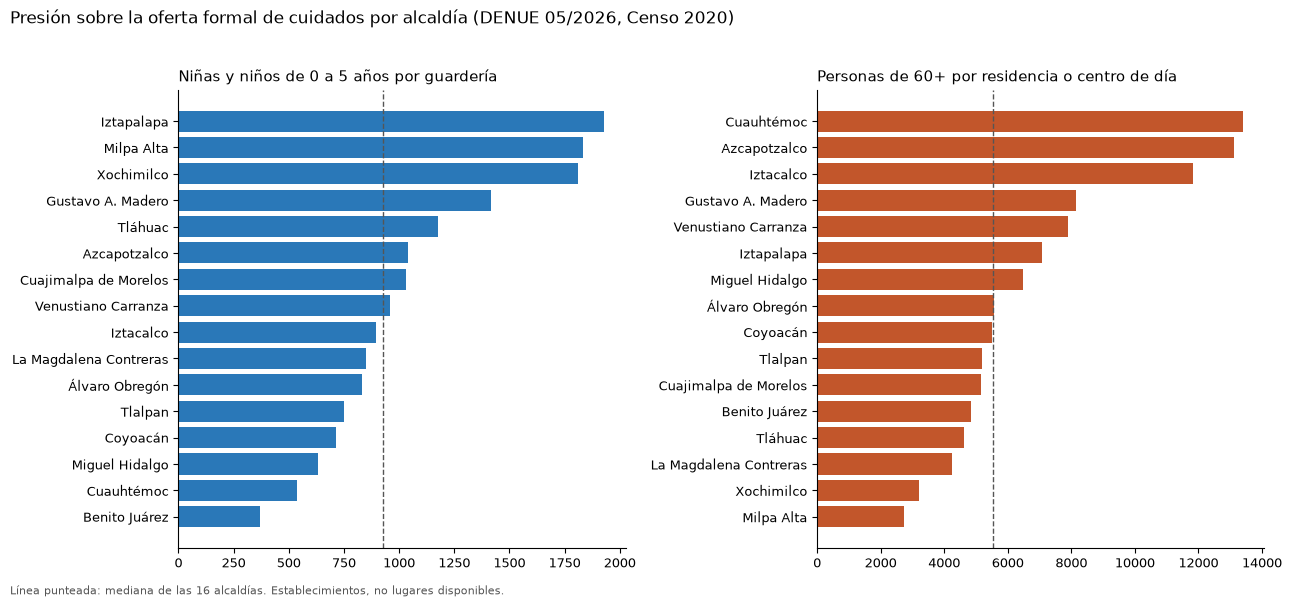

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=False)
for ax, col, titulo, color in [
    (axes[0], 'ninos_0a5_por_guarderia', 'Niñas y niños de 0 a 5 años por guardería', '#2a78b8'),
    (axes[1], 'mayores_60_por_establecimiento', 'Personas de 60+ por residencia o centro de día', '#c2562b'),
]:
    d = cruce.sort_values(col)
    ax.barh(d['alcaldia'], d[col], color=color)
    ax.axvline(cruce[col].median(), color='#555', ls='--', lw=1)
    ax.set_title(titulo, fontsize=11, loc='left')
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=9)
fig.suptitle('Presión sobre la oferta formal de cuidados por alcaldía (DENUE 05/2026, Censo 2020)', x=0.01, ha='left', fontsize=12)
fig.text(0.01, 0.005, 'Línea punteada: mediana de las 16 alcaldías. Establecimientos, no lugares disponibles.', fontsize=8, color='#555')
plt.tight_layout(rect=(0, 0.02, 1, 0.96))
fig.savefig(FIG / 'presion_oferta_alcaldia.png', dpi=150)
plt.show()

---
## 4. Prueba exploratoria de H1 y H2 a nivel AGEB

**Método.** El CSV del Censo no trae coordenadas de las AGEB. Como aproximación usamos el **centroide aproximado de cada AGEB**: la mediana de latitud y longitud de todos los establecimientos del DENUE registrados en esa AGEB (462 mil establecimientos cubren casi todas las AGEB urbanas). Luego contamos cuántos establecimientos de cuidado hay a **1 km** (unos 12–15 minutos a pie).

> ⚠️ Es una aproximación exploratoria. Para el entregable final hay que usar los polígonos oficiales del Marco Geoestadístico del INEGI.

- **H1 — brecha intra-alcaldía:** ¿qué parte de la desigualdad en acceso se explica por diferencias *entre* alcaldías y qué parte *dentro* de ellas? (descomposición de varianza, η²)
- **H2 — desiertos de cuidado:** AGEB en el cuartil más alto de población demandante y **cero** establecimientos a 1 km.

In [10]:
denue['lat'] = pd.to_numeric(denue['latitud'], errors='coerce')
denue['lon'] = pd.to_numeric(denue['longitud'], errors='coerce')
denue['CVEGEO_AGEB'] = denue['cve_ent'] + denue['cve_mun'] + denue['cve_loc'] + denue['ageb']
centroides = denue.dropna(subset=['lat', 'lon']).groupby('CVEGEO_AGEB')[['lat', 'lon']].median()

geo = ageb.merge(centroides, left_on='CVEGEO_AGEB', right_index=True, how='left')
print(f"AGEB con centroide aproximado: {geo['lat'].notna().sum():,} de {len(geo):,} "
      f"({geo['lat'].notna().mean() * 100:.1f}%) · población cubierta: "
      f"{geo.loc[geo['lat'].notna(), 'pob_total'].sum() / geo['pob_total'].sum() * 100:.1f}%")

RADIO_KM = 1.0
R_TIERRA = 6371.0
geo = geo.dropna(subset=['lat', 'lon']).copy()
pts = np.radians(geo[['lat', 'lon']].to_numpy())

def contar_en_radio(tipos):
    est = cuidado[cuidado['tipo'].isin(tipos)].dropna(subset=['lat', 'lon'])
    arbol = BallTree(np.radians(est[['lat', 'lon']].to_numpy()), metric='haversine')
    return arbol.query_radius(pts, r=RADIO_KM / R_TIERRA, count_only=True)

geo['guarderias_1km'] = contar_en_radio(['Guardería'])
geo['cuidado_mayores_1km'] = contar_en_radio(['Residencia / asilo', 'Centro de día'])
geo[['guarderias_1km', 'cuidado_mayores_1km']].describe().round(1)

AGEB con centroide aproximado: 2,420 de 2,433 (99.5%) · población cubierta: 99.9%


,guarderias_1km,cuidado_mayores_1km
count,2420.0,2420.0
mean,2.9,1.1
std,2.3,1.3
min,0.0,0.0
25%,1.0,0.0
50%,3.0,1.0
75%,4.0,2.0
max,12.0,7.0


### H1 — ¿la desigualdad está entre alcaldías o dentro de ellas?

In [11]:
def eta_cuadrada(df, y, grupo='MUN'):
    """Proporción de la varianza de y explicada por la alcaldía (entre grupos)."""
    media = df[y].mean()
    g = df.groupby(grupo)[y].agg(['mean', 'size'])
    ss_entre = (g['size'] * (g['mean'] - media) ** 2).sum()
    ss_total = ((df[y] - media) ** 2).sum()
    return ss_entre / ss_total

h1 = pd.DataFrame({
    'indicador': ['Guarderías a 1 km', 'Residencias y centros de día a 1 km'],
    '% varianza ENTRE alcaldías': [eta_cuadrada(geo, 'guarderias_1km') * 100,
                                    eta_cuadrada(geo, 'cuidado_mayores_1km') * 100],
}).round(1)
h1['% varianza DENTRO de alcaldías'] = (100 - h1['% varianza ENTRE alcaldías']).round(1)
h1

,indicador,% varianza ENTRE alcaldías,% varianza DENTRO de alcaldías
0,Guarderías a 1 km,33.3,66.7
1,Residencias y centros de día a 1 km,5.7,94.3


### H2 — desiertos de cuidado

In [12]:
umbral_ninos = geo['pob_0a5'].quantile(0.75)
umbral_mayores = geo['pob_60mas'].quantile(0.75)

geo['desierto_infancia'] = (geo['pob_0a5'] >= umbral_ninos) & (geo['guarderias_1km'] == 0)
geo['desierto_mayores'] = (geo['pob_60mas'] >= umbral_mayores) & (geo['cuidado_mayores_1km'] == 0)

print(f'Umbral cuartil superior: {umbral_ninos:.0f} niñas/os de 0–5 · {umbral_mayores:.0f} personas de 60+ por AGEB')
resumen_h2 = pd.DataFrame({
    'AGEB desierto': [geo['desierto_infancia'].sum(), geo['desierto_mayores'].sum()],
    'Población demandante que vive ahí': [geo.loc[geo['desierto_infancia'], 'pob_0a5'].sum(),
                                          geo.loc[geo['desierto_mayores'], 'pob_60mas'].sum()],
}, index=['Infancia (0–5, sin guardería a 1 km)', 'Personas mayores (60+, sin residencia ni centro de día a 1 km)'])
resumen_h2['Población demandante que vive ahí'] = resumen_h2['Población demandante que vive ahí'].astype(int)
resumen_h2

Umbral cuartil superior: 332 niñas/os de 0–5 · 822 personas de 60+ por AGEB


,AGEB desierto,Población demandante que vive ahí
"Infancia (0–5, sin guardería a 1 km)",91,45447
"Personas mayores (60+, sin residencia ni centro de día a 1 km)",256,276246


In [13]:
nombres = alc.set_index('cve_mun')['alcaldia']
por_alc = (geo.groupby('MUN')[['desierto_infancia', 'desierto_mayores']].sum()
              .join(geo.groupby('MUN').size().rename('agebs'))
              .rename(index=nombres))
por_alc['% AGEB desierto mayores'] = (por_alc['desierto_mayores'] / por_alc['agebs'] * 100).round(1)
por_alc.sort_values('desierto_mayores', ascending=False)

,desierto_infancia,desierto_mayores,agebs,% AGEB desierto mayores
MUN,,,,
Iztapalapa,32,37,457,8.1
Gustavo A. Madero,11,30,305,9.8
Azcapotzalco,6,29,103,28.2
Coyoacán,1,23,156,14.7
Cuauhtémoc,0,22,152,14.5
Iztacalco,0,21,110,19.1
Tlalpan,10,17,204,8.3
Álvaro Obregón,1,16,196,8.2
Venustiano Carranza,0,13,151,8.6


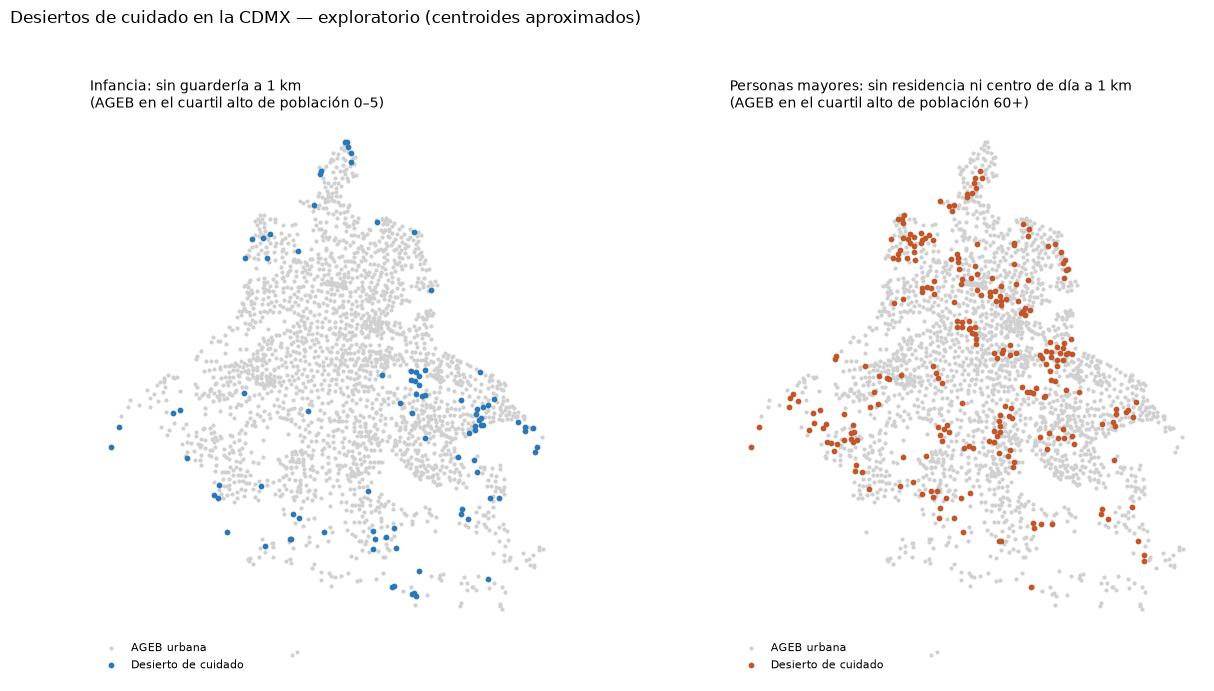

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 7))
for ax, flag, col, titulo, color in [
    (axes[0], 'desierto_infancia', 'guarderias_1km', 'Infancia: sin guardería a 1 km\n(AGEB en el cuartil alto de población 0–5)', '#2a78b8'),
    (axes[1], 'desierto_mayores', 'cuidado_mayores_1km', 'Personas mayores: sin residencia ni centro de día a 1 km\n(AGEB en el cuartil alto de población 60+)', '#c2562b'),
]:
    ax.scatter(geo['lon'], geo['lat'], s=4, color='#d0d0d0', label='AGEB urbana')
    d = geo[geo[flag]]
    ax.scatter(d['lon'], d['lat'], s=10, color=color, label='Desierto de cuidado')
    ax.set_title(titulo, fontsize=10, loc='left')
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines[:].set_visible(False)
    ax.legend(loc='lower left', fontsize=8, frameon=False)
fig.suptitle('Desiertos de cuidado en la CDMX — exploratorio (centroides aproximados)', x=0.01, ha='left', fontsize=12)
plt.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(FIG / 'desiertos_cuidado_ageb.png', dpi=150)
plt.show()

In [15]:
geo.to_csv(CUR / 'ageb_acceso_cuidado_cdmx.csv', index=False)

---
## 5. ENUT 2024 — horas de cuidado no remunerado, CDMX vs. nacional

La ENUT sí trae la entidad (`cve_ent`) y factor de expansión (`fac_per`), y está diseñada para ser representativa por entidad federativa.

**Validación primero.** Antes de sacar conclusiones, reproducimos las cifras oficiales que publicó el INEGI: tiempo total de trabajo de 59.6 h/semana (mujeres 61.1, hombres 58.0). Si cuadran, el método (factores de expansión y promedios entre quienes realizan la actividad) es correcto.

In [16]:
enut = pd.read_csv(next(DIRS['enut_2024'].rglob('*tvar_crea*/conjunto_de_datos/*.csv')),
                   dtype=str, encoding='utf-8-sig')
horas = list(enut.columns[3:41])
for c in horas + ['fac_per', 'edad']:
    enut[c] = pd.to_numeric(enut[c], errors='coerce')
enut['sexo_t'] = enut['sexo'].map({'1': 'Hombres', '2': 'Mujeres'})

def prom_participantes(d, col):
    d = d[d[col] > 0]
    return np.average(d[col], weights=d['fac_per'])

def participacion(d, col):
    return (d.loc[d[col] > 0, 'fac_per'].sum() / d['fac_per'].sum()) * 100

val = pd.Series({
    'Total': prom_participantes(enut, 'activ_prod_sin_cp'),
    'Mujeres': prom_participantes(enut[enut['sexo_t'] == 'Mujeres'], 'activ_prod_sin_cp'),
    'Hombres': prom_participantes(enut[enut['sexo_t'] == 'Hombres'], 'activ_prod_sin_cp'),
}).round(1)
print('Tiempo total de trabajo (h/semana) — INEGI publicó 59.6 / 61.1 / 58.0')
print(val.to_string())
print(f"\nMuestra ENUT CDMX: {(enut['cve_ent'] == '09').sum():,} personas de 12+ · nacional: {len(enut):,}")

Tiempo total de trabajo (h/semana) — INEGI publicó 59.6 / 61.1 / 58.0
Total      59.6
Mujeres    61.1
Hombres    58.0

Muestra ENUT CDMX: 2,107 personas de 12+ · nacional: 74,053


In [17]:
ACTIV = {
    'trab_no_rem_cuid_hog': 'Cuidado a integrantes del hogar (total)',
    'cuid_int_0a5_sin_cp': 'Cuidado a niñas/os de 0 a 5',
    'cuid_int_60mas_sin_cp': 'Cuidado a personas de 60+',
    'cuid_esp_int_hog_sin_cp': 'Cuidados especiales (enfermedad o discapacidad)',
}
filas = []
for amb, d0 in [('CDMX', enut[enut['cve_ent'] == '09']), ('Nacional', enut)]:
    for sexo in ['Mujeres', 'Hombres']:
        d = d0[d0['sexo_t'] == sexo]
        for col, nombre in ACTIV.items():
            filas.append({'ámbito': amb, 'sexo': sexo, 'actividad': nombre,
                          '% que lo realiza': participacion(d, col),
                          'h/semana (quienes lo realizan)': prom_participantes(d, col),
                          'n muestral': int((d[col] > 0).sum())})
enut_tab = pd.DataFrame(filas).round(1)
enut_tab.to_csv(CUR / 'enut2024_cuidados_cdmx_vs_nacional.csv', index=False)
enut_tab.pivot_table(index='actividad', columns=['ámbito', 'sexo'],
                     values=['% que lo realiza', 'h/semana (quienes lo realizan)'])

% que lo realiza                          h/semana (quienes lo realizan)                         
ámbito                                                      CDMX         Nacional                                   CDMX         Nacional        
sexo                                                     Hombres Mujeres  Hombres Mujeres                        Hombres Mujeres  Hombres Mujeres
actividad                                                                                                                                        
Cuidado a integrantes del hogar (total)                     60.0    62.2     64.2    70.9                            8.1    12.2      8.7    13.6
Cuidado a niñas/os de 0 a 5                                  8.8    10.9     14.6    19.0                            9.9    21.0      8.8    18.2
Cuidado a personas de 60+                                   13.0    11.3      9.9    10.0                            4.9     4.8      4.3     4.7
Cuidados especiales (enfermedad o discapacidad)              6.0     7.2      6.8     8.8                            6.5    13.8      7.5    12.8

> **Ojo con el tamaño de muestra en CDMX:** la columna `n muestral` dice cuántas personas encuestadas sostienen cada cifra. Donde sea menor a ~100 (por ejemplo, hombres que cuidan a personas de 60+), la cifra es orientativa y no conviene presentarla como hallazgo sin su error estándar.

In [18]:
cdmx_total = enut_tab[(enut_tab['ámbito'] == 'CDMX') & (enut_tab['actividad'] == ACTIV['trab_no_rem_cuid_hog'])].set_index('sexo')
m, h = cdmx_total.loc['Mujeres'], cdmx_total.loc['Hombres']
carga_m = m['% que lo realiza'] / 100 * m['h/semana (quienes lo realizan)']
carga_h = h['% que lo realiza'] / 100 * h['h/semana (quienes lo realizan)']
print(f'CDMX — horas promedio de cuidado por persona de 12+ (incluye a quien no cuida):')
print(f'  Mujeres {carga_m:.1f} h/semana · Hombres {carga_h:.1f} h/semana · razón {carga_m / carga_h:.1f} a 1')

CDMX — horas promedio de cuidado por persona de 12+ (incluye a quien no cuida):
  Mujeres 7.6 h/semana · Hombres 4.9 h/semana · razón 1.6 a 1


---
## 6. ENASIC 2022 — qué se puede y qué no

**Hallazgo clave:** los microdatos públicos de ENASIC (tanto la versión de *datos abiertos* como la de *microdatos*) **no traen ningún identificador geográfico**: ni entidad, ni municipio, ni tamaño de localidad. No es solo que la muestra sea chica para la CDMX: **no se puede aislar la CDMX en absoluto**.

Por lo tanto, ENASIC sirve únicamente para **perfiles y tasas nacionales** (quién cuida, cuántas horas, qué impacto tiene en su vida laboral), que después se contrastan con los datos de CDMX de la ENUT y el Censo.

In [19]:
tablas = {}
for f in sorted(DIRS['enasic_2022'].rglob('conjunto_de_datos/*.csv')):
    df = pd.read_csv(f, dtype=str, encoding='utf-8-sig', low_memory=False)
    tablas[f.stem.replace('conjunto_de_datos_', '').replace('_enasic_2022', '')] = df

geo_cols = ['ENT', 'CVE_ENT', 'ENTIDAD', 'MUN', 'CVE_MUN', 'TLOC', 'T_LOC', 'CVEGEO']
pd.DataFrame([{'tabla': k, 'registros': len(v), 'variables': v.shape[1],
               'factor': next((c for c in v.columns if c.upper().startswith('FAC')), None),
               'variables geográficas': [c for c in v.columns if c.upper() in geo_cols] or 'ninguna'}
              for k, v in tablas.items()])

,tabla,registros,variables,factor,variables geográficas
0,tcsdempo,21776,181,FAC_HOG,ninguna
1,thog_unip,928,315,FAC_UNI,ninguna
2,thogar_ensasic_2022,6508,72,FAC_HOG,ninguna
3,tper_ele,5579,275,FAC_ELE,ninguna
4,tpob_cui,5677,432,FAC_CUI,ninguna
5,tvivienda,6423,44,FAC_VIV,ninguna


In [20]:
cui = tablas['tpob_cui'].copy()   # ya trae SEXO y EDAD de la persona cuidadora
cui['FAC_CUI'] = pd.to_numeric(cui['FAC_CUI'])
cui['EDAD'] = pd.to_numeric(cui['EDAD'], errors='coerce')

tot = cui['FAC_CUI'].sum()
muj = cui.loc[cui['SEXO'] == '2', 'FAC_CUI'].sum()
print(f'Personas cuidadoras de 15+ (estimación nacional): {tot / 1e6:.1f} millones')
print(f'  % mujeres: {muj / tot * 100:.1f}%')
print(f'  Edad mediana ponderada: {cui.loc[cui.EDAD.notna()].sort_values("EDAD").pipe(lambda d: d.EDAD[d.FAC_CUI.cumsum() >= d.FAC_CUI.sum() / 2].iloc[0]):.0f} años')
print(f'  Registros muestrales: {len(cui):,}')

Personas cuidadoras de 15+ (estimación nacional): 31.7 millones
  % mujeres: 75.1%
  Edad mediana ponderada: 39 años
  Registros muestrales: 5,677


---
## 7. Resumen de hallazgos

_Ver la celda siguiente para las cifras calculadas; la interpretación está en el resumen para el equipo._

In [21]:
resumen = {
    'Establecimientos de cuidado (DENUE 05/2026)': len(cuidado),
    'Guarderías': int((cuidado['tipo'] == 'Guardería').sum()),
    'Residencias/asilos para personas mayores': int((cuidado['tipo'] == 'Residencia / asilo').sum()),
    'Centros de día mayores/discapacidad': int((cuidado['tipo'] == 'Centro de día').sum()),
    'AGEB urbanas analizadas': len(geo),
    'H1 · % varianza DENTRO de alcaldías (guarderías)': h1.loc[0, '% varianza DENTRO de alcaldías'],
    'H1 · % varianza DENTRO de alcaldías (cuidado mayores)': h1.loc[1, '% varianza DENTRO de alcaldías'],
    'H2 · AGEB desierto infancia': int(geo['desierto_infancia'].sum()),
    'H2 · AGEB desierto personas mayores': int(geo['desierto_mayores'].sum()),
    'H2 · personas 60+ en desiertos': int(geo.loc[geo['desierto_mayores'], 'pob_60mas'].sum()),
}
pd.Series(resumen)

Establecimientos de cuidado (DENUE 05/2026)                1463.0
Guarderías                                                  603.0
Residencias/asilos para personas mayores                    109.0
Centros de día mayores/discapacidad                         126.0
AGEB urbanas analizadas                                    2420.0
H1 · % varianza DENTRO de alcaldías (guarderías)             66.7
H1 · % varianza DENTRO de alcaldías (cuidado mayores)        94.3
H2 · AGEB desierto infancia                                  91.0
H2 · AGEB desierto personas mayores                         256.0
H2 · personas 60+ en desiertos                           276246.0
dtype: float64